# Phase 2 · 2단원 — 선형 회귀

> **데이터를 뚫고 지나가는 가장 좋은 직선 하나를 찾는 일입니다. 머신러닝의 "Hello World"예요.**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/02-linear-regression>
- 예상 시간: 90분 · 선수 지식: 1단원

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **경사하강법**으로 직선을 찾는 방법을 밑바닥부터 만듭니다.
2. **정규방정식**(한 번에 푸는 공식)과 비교하고, 언제 뭘 쓸지 판단합니다.
3. 입력이 **여러 개**일 때로 확장하고, 왜 **스케일 맞추기**가 필요한지 봅니다.
4. **릿지 회귀**가 어떻게 과적합을 막는지 이해합니다.

### 🔑 사실 이 단원의 진짜 목표는 따로 있습니다

원문이 이렇게 말합니다.

> "선형 회귀는 **머신러닝 훈련 과정 전체**를 소개한다.
> 모델을 정하고, 비용 함수를 정하고, 파라미터를 최적화한다.
> **모든 ML 알고리즘이 이 패턴을 따른다.**"

즉 이 단원은 직선 긋기가 아니라 **"기계가 배운다는 게 뭔지"** 를 배우는 자리입니다.
여기서 익힌 3단계를 앞으로 계속 다시 보게 됩니다.

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 집값 예측 문제 | 📗 원문 |
| 1 | 모델 — 직선 하나 `y = wx + b` | 📗 원문 + ✨ 손 계산 |
| 2 | 비용 함수 — 얼마나 틀렸나 재기 | 📗 원문 + ✨ 실험 |
| 3 | 🔑 경사하강법 — 눈 감고 산 내려오기 | 📗 원문 + ✨ 비유·그림 |
| 4 | 🔨 직접 만들어 보기 | 📗 원문 |
| 5 | 학습률 — 보폭을 잘못 정하면 | 📗 원문 + ✨ 실험 |
| 6 | 정규방정식 — 한 번에 푸는 공식 | 📗 원문 |
| 7 | 입력이 여러 개일 때 + 스케일 맞추기 | 📗 원문 + ✨ 실험 |
| 8 | 다항 회귀 — 곡선도 직선으로 | 📗 원문 |
| 9 | R² 점수 — 몇 점짜리 모델인가 | 📗 원문 |
| 10 | 릿지 회귀 맛보기 | 📗 원문 |
| 11 | 용어 사전 · 연습문제 | 📗 원문 |

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 집값 예측 문제

> 📗 **원문** — "The Problem"

집 **크기**와 **가격** 데이터가 있습니다. 새 집의 크기를 알 때 가격을 맞히고 싶어요.

점을 찍어 놓고 눈대중으로 선을 그을 수도 있습니다. 그런데 **공식**이 필요합니다.
크기를 넣으면 가격이 나오는 공식이요.

**선형 회귀가 바로 그 선을 찾아 줍니다.**

> 💡 단순해 보여도 실무에서 계속 씁니다.
> 수요 예측, A/B 테스트 분석, 금융 모델링, 그리고 **모든 회귀 문제의 기준선**으로요.

> ✨ **추가** — 먼저 데이터를 만들고 눈으로 봅시다.

In [2]:
# 📗 원문의 데이터 생성 설정을 그대로 씁니다 (진짜 답: y = 3x + 7)
진짜_기울기 = 3.0     # w (weight)
진짜_절편 = 7.0       # b (bias)

rng = np.random.default_rng(42)
X = rng.uniform(0, 10, 100)                                    # 집 크기 (평)
y = 진짜_기울기 * X + 진짜_절편 + rng.normal(0, 2.0, 100)      # 가격 (+ 잡음)

print(f"데이터 {len(X)}개를 만들었습니다.")
print(f"진짜 관계식: y = {진짜_기울기}x + {진짜_절편}  (여기에 잡음이 섞임)\n")
print("앞의 5개만 보면:")
for i in range(5):
    print(f"  크기 {X[i]:5.2f}  ->  가격 {y[i]:6.2f}")

print("\n⚠️ 우리는 '진짜 관계식'을 안다고 치고 데이터를 만들었지만,")
print("   실제 상황에서는 이걸 모릅니다. 점만 보고 찾아내야 해요.")
print("   그게 이 단원에서 할 일입니다.")

데이터 100개를 만들었습니다.
진짜 관계식: y = 3.0x + 7.0  (여기에 잡음이 섞임)

앞의 5개만 보면:
  크기  7.74  ->  가격  31.02
  크기  4.39  ->  가격  18.36
  크기  8.59  ->  가격  32.00
  크기  6.97  ->  가격  30.52
  크기  0.94  ->  가격   9.11

⚠️ 우리는 '진짜 관계식'을 안다고 치고 데이터를 만들었지만,
   실제 상황에서는 이걸 모릅니다. 점만 보고 찾아내야 해요.
   그게 이 단원에서 할 일입니다.


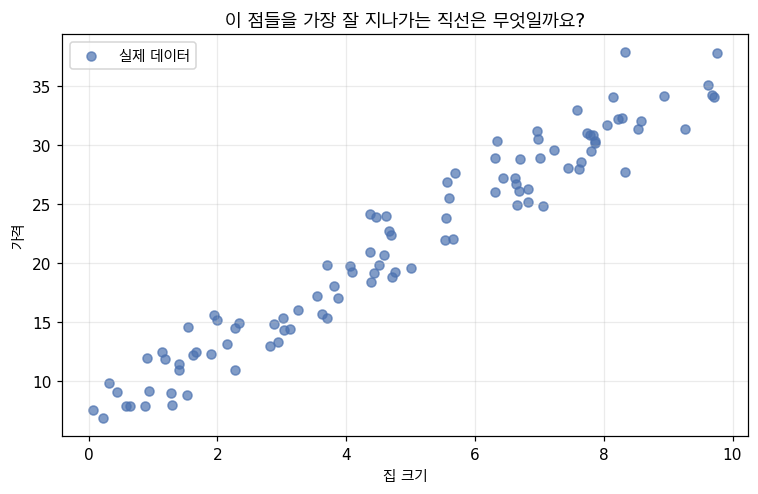

눈으로 보면 '오른쪽 위로 올라가는 직선'이라는 건 알겠습니다.
그런데 정확히 '어떤' 직선일까요? 그걸 컴퓨터가 찾게 하는 게 목표입니다.


In [3]:
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(X, y, s=35, color="#4c72b0", alpha=0.7, label="실제 데이터")
ax.set_xlabel("집 크기"); ax.set_ylabel("가격")
ax.set_title("이 점들을 가장 잘 지나가는 직선은 무엇일까요?", fontsize=12.5)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("눈으로 보면 '오른쪽 위로 올라가는 직선'이라는 건 알겠습니다.")
print("그런데 정확히 '어떤' 직선일까요? 그걸 컴퓨터가 찾게 하는 게 목표입니다.")

## 1️⃣ 모델 — 직선 하나

> 📗 **원문** — "The Model"

선형 회귀는 입력과 출력이 **직선 관계**라고 가정합니다.

$$y = wx + b$$

딱 두 개의 숫자만 정하면 직선이 결정됩니다.

| 기호 | 이름 | 뜻 |
| --- | --- | --- |
| **`w`** | 가중치(weight) · 기울기 | **`x`가 1 늘어날 때 `y`가 얼마나 변하나** |
| **`b`** | 편향(bias) · 절편 | **`x`가 0일 때 `y`값** |

### 🧸 쉽게 말하면

- **`w`는 "경사"입니다.** 크면 가파르게 올라가고, 작으면 완만합니다.
- **`b`는 "출발 높이"입니다.** 선 전체를 위아래로 옮깁니다.

> 🔑 **모델을 찾는다 = 이 숫자 두 개를 찾는다**
>
> 1단원에서 "모델은 규칙을 숫자로 적어 놓은 것"이라고 했죠.
> 여기서는 그 숫자가 딱 **2개**입니다. `w`와 `b`.

### 입력이 여러 개면

$$y = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b$$

집 크기뿐 아니라 방 개수, 지은 연도까지 쓰는 거예요. (7절에서 다룹니다)

> ✨ **추가** — `w`와 `b`를 바꾸면 직선이 어떻게 움직이는지 눈으로 봅시다.

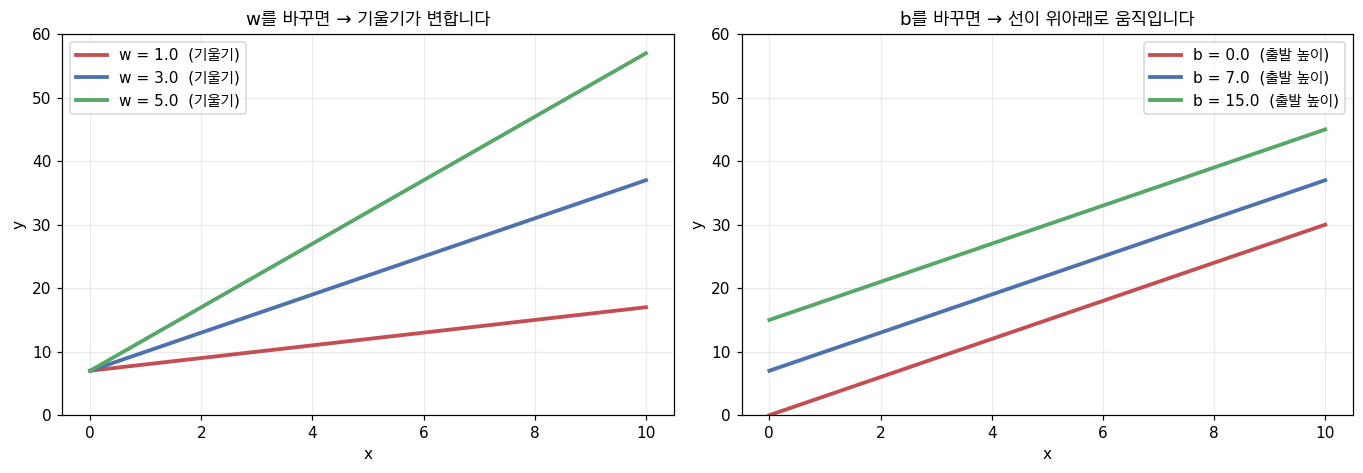

이 두 손잡이(w, b)만 잘 돌리면 어떤 직선이든 만들 수 있습니다.
문제는 '어디로 돌려야 하는가'입니다. 그걸 2~3절에서 알아냅니다.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
xs = np.linspace(0, 10, 100)

# w를 바꿔 보기
for w, c in [(1.0, "#c44e52"), (3.0, "#4c72b0"), (5.0, "#55a868")]:
    ax1.plot(xs, w * xs + 7, lw=2.5, color=c, label=f"w = {w}  (기울기)")
ax1.set_title("w를 바꾸면 → 기울기가 변합니다", fontsize=12)
ax1.set_xlabel("x"); ax1.set_ylabel("y")
ax1.legend(fontsize=10); ax1.grid(alpha=0.25); ax1.set_ylim(0, 60)

# b를 바꿔 보기
for b, c in [(0.0, "#c44e52"), (7.0, "#4c72b0"), (15.0, "#55a868")]:
    ax2.plot(xs, 3 * xs + b, lw=2.5, color=c, label=f"b = {b}  (출발 높이)")
ax2.set_title("b를 바꾸면 → 선이 위아래로 움직입니다", fontsize=12)
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.legend(fontsize=10); ax2.grid(alpha=0.25); ax2.set_ylim(0, 60)

plt.tight_layout()
plt.show()

print("이 두 손잡이(w, b)만 잘 돌리면 어떤 직선이든 만들 수 있습니다.")
print("문제는 '어디로 돌려야 하는가'입니다. 그걸 2~3절에서 알아냅니다.")

## 2️⃣ 비용 함수 — 얼마나 틀렸나 재기

> 📗 **원문** — "The Cost Function (Mean Squared Error)"

"가장 잘 맞는 직선"을 찾으려면, 먼저 **"얼마나 안 맞는지"를 숫자 하나로** 나타내야 합니다.

가장 많이 쓰는 게 **평균제곱오차(MSE)** 입니다.

$$\text{MSE} = \frac{1}{n}\sum(\text{예측값} - \text{실제값})^2$$

### 🧸 말로 풀면

1. 각 점마다 **예측이 얼마나 빗나갔는지** 잽니다 (예측 − 실제)
2. 그걸 **제곱**합니다
3. 전부 더해서 **평균**을 냅니다

### 🔑 왜 제곱을 하나요? (두 가지 이유)

**① 크게 틀린 걸 더 크게 벌주려고**

10만큼 틀린 것은 1만큼 틀린 것보다 **10배가 아니라 100배** 나쁩니다.
"조금씩 자주 틀리는 것"보다 "가끔 크게 틀리는 것"을 더 싫어하게 만드는 거예요.

**② 부호를 없애려고**

+5만큼 틀린 것과 −5만큼 틀린 것은 **똑같이 나쁩니다.**
그냥 더하면 서로 상쇄돼 버립니다. 제곱하면 둘 다 25가 돼요.

**③ (숨은 이유) 계산이 매끄러워서**

제곱 함수는 **어디서나 미분이 됩니다.** 3절의 경사하강법이 이 성질을 씁니다.

### 🔑 비용 함수는 '그릇' 모양입니다

`w`와 `b`를 이리저리 바꿔 가며 MSE를 계산해 보면, **밥그릇 같은 모양**이 나옵니다.
**그릇의 바닥이 정답**이에요. 학습이란 그 바닥을 찾아가는 일입니다.

> ✨ **추가** — 아주 작은 데이터로 MSE를 손으로 계산해 봅시다.

In [5]:
# ✨ 추가 — 점 3개만 놓고 손으로 따라가 봅니다.
작은_X = np.array([1.0, 2.0, 3.0])
작은_y = np.array([10.0, 13.0, 16.0])       # 진짜 관계는 y = 3x + 7

def MSE_계산(w, b, X, y, 자세히=False):
    예측 = w * X + b
    오차 = 예측 - y
    if 자세히:
        print(f"  w={w}, b={b} 일 때")
        print(f"  {'x':>6}{'실제 y':>10}{'예측값':>10}{'오차':>10}{'오차²':>10}")
        print("  " + "-" * 46)
        for xi, yi, pi, ei in zip(X, y, 예측, 오차):
            print(f"  {xi:>6.1f}{yi:>10.1f}{pi:>10.1f}{ei:>10.1f}{ei**2:>10.2f}")
        print(f"  {'':>36}합계 {np.sum(오차**2):>8.2f}")
        print(f"  MSE = 합계 / 개수 = {np.sum(오차**2):.2f} / {len(X)} = {np.mean(오차**2):.3f}\n")
    return np.mean(오차 ** 2)

print("[엉터리 직선] y = 1x + 1 로 예측해 보면")
MSE_계산(1.0, 1.0, 작은_X, 작은_y, 자세히=True)

print("[정답 직선] y = 3x + 7 로 예측해 보면")
MSE_계산(3.0, 7.0, 작은_X, 작은_y, 자세히=True)

print("=> 정답 직선의 MSE가 0입니다. 완벽하게 맞혔다는 뜻이에요.")
print("   MSE가 작을수록 좋은 직선입니다. 그래서 'MSE를 최소로 만드는 w, b 찾기'가 목표가 됩니다.")

[엉터리 직선] y = 1x + 1 로 예측해 보면
  w=1.0, b=1.0 일 때
       x      실제 y       예측값        오차       오차²
  ----------------------------------------------
     1.0      10.0       2.0      -8.0     64.00
     2.0      13.0       3.0     -10.0    100.00
     3.0      16.0       4.0     -12.0    144.00
                                      합계   308.00
  MSE = 합계 / 개수 = 308.00 / 3 = 102.667

[정답 직선] y = 3x + 7 로 예측해 보면
  w=3.0, b=7.0 일 때
       x      실제 y       예측값        오차       오차²
  ----------------------------------------------
     1.0      10.0      10.0       0.0      0.00
     2.0      13.0      13.0       0.0      0.00
     3.0      16.0      16.0       0.0      0.00
                                      합계     0.00
  MSE = 합계 / 개수 = 0.00 / 3 = 0.000

=> 정답 직선의 MSE가 0입니다. 완벽하게 맞혔다는 뜻이에요.
   MSE가 작을수록 좋은 직선입니다. 그래서 'MSE를 최소로 만드는 w, b 찾기'가 목표가 됩니다.


> ✨ **추가 그림** — 비용 함수가 정말 '그릇 모양'인지 확인합니다.

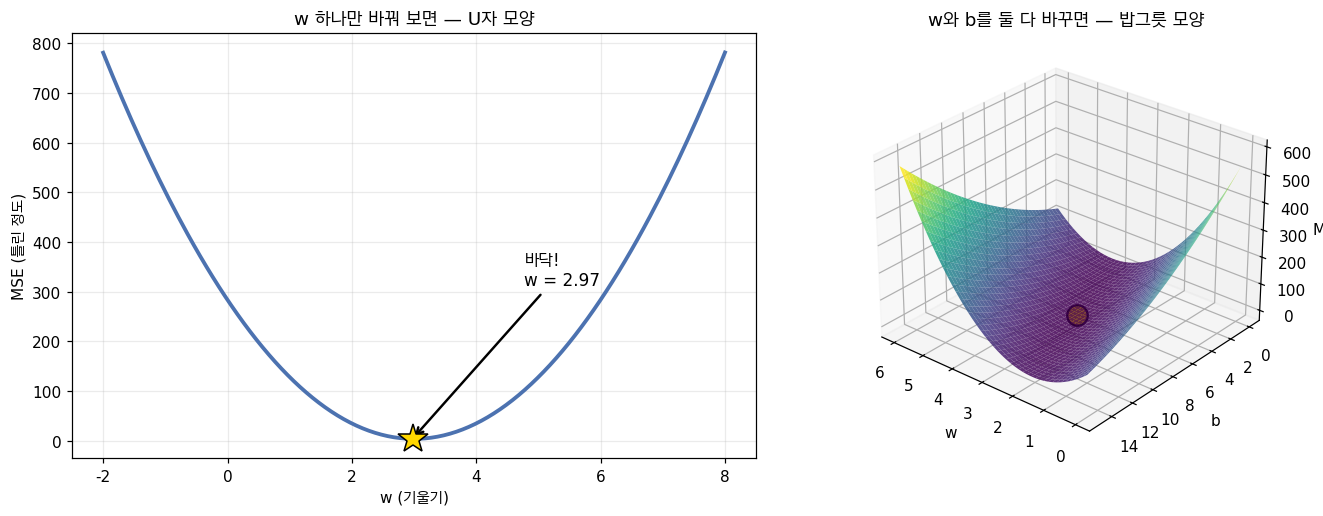

오른쪽 그림이 이 절의 핵심입니다.
노란 별이 '그릇의 바닥' = 우리가 찾고 싶은 정답입니다.

💡 학습이란 이 그릇 위 아무 데나 공을 놓고, 바닥까지 굴러가게 하는 일입니다.
   문제는 컴퓨터가 이 그릇 전체를 볼 수 없다는 것입니다. 다음 절에서 다룹니다.


In [6]:
fig = plt.figure(figsize=(13, 4.8))

# 왼쪽: w만 바꿔 가며 MSE 보기 (b는 정답으로 고정)
ax1 = fig.add_subplot(1, 2, 1)
w_후보 = np.linspace(-2, 8, 200)
비용들 = [MSE_계산(w, 진짜_절편, X, y) for w in w_후보]
ax1.plot(w_후보, 비용들, lw=2.5, color="#4c72b0")
최소w = w_후보[int(np.argmin(비용들))]
ax1.plot(최소w, min(비용들), "*", ms=20, color="gold", markeredgecolor="black", zorder=5)
ax1.annotate(f"바닥!\nw = {최소w:.2f}", (최소w, min(비용들)),
             xytext=(최소w + 1.8, max(비용들) * 0.4), fontsize=11,
             arrowprops=dict(arrowstyle="->", lw=1.6))
ax1.set_xlabel("w (기울기)"); ax1.set_ylabel("MSE (틀린 정도)")
ax1.set_title("w 하나만 바꿔 보면 — U자 모양", fontsize=12)
ax1.grid(alpha=0.25)

# 오른쪽: w와 b를 둘 다 바꿔 가며 (그릇 모양)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
w격자, b격자 = np.meshgrid(np.linspace(0, 6, 45), np.linspace(0, 15, 45))
비용격자 = np.array([[MSE_계산(w, b, X, y) for w in np.linspace(0, 6, 45)]
                     for b in np.linspace(0, 15, 45)])
ax2.plot_surface(w격자, b격자, 비용격자, cmap="viridis", alpha=0.85)
ax2.scatter([진짜_기울기], [진짜_절편],
            [MSE_계산(진짜_기울기, 진짜_절편, X, y)],
            s=180, color="gold", edgecolor="black", linewidth=1.5, zorder=10)
ax2.set_xlabel("w"); ax2.set_ylabel("b"); ax2.set_zlabel("MSE")
ax2.set_title("w와 b를 둘 다 바꾸면 — 밥그릇 모양", fontsize=12)
ax2.view_init(elev=28, azim=130)

plt.tight_layout()
plt.show()

print("오른쪽 그림이 이 절의 핵심입니다.")
print("노란 별이 '그릇의 바닥' = 우리가 찾고 싶은 정답입니다.")
print("\n💡 학습이란 이 그릇 위 아무 데나 공을 놓고, 바닥까지 굴러가게 하는 일입니다.")
print("   문제는 컴퓨터가 이 그릇 전체를 볼 수 없다는 것입니다. 다음 절에서 다룹니다.")

## 3️⃣ 🔑 경사하강법 — 눈 감고 산 내려오기

> 📗 **원문** — "Gradient Descent"
>
> **이 절이 이 단원에서 가장 중요합니다.** 앞으로 모든 딥러닝이 이걸 씁니다.

### 🧸 비유 — 안개 낀 산에서 내려오기

깜깜한 밤, 안개 낀 산에 서 있습니다. **산 아래로 내려가야 하는데 앞이 안 보입니다.**

어떻게 할까요?

1. **발끝으로 땅을 더듬어 봅니다.** 어느 쪽이 내리막인지 느낍니다
2. **가장 가파른 내리막 방향으로 한 걸음** 내딛습니다
3. 다시 더듬어 봅니다. 또 한 걸음
4. **평평해질 때까지 반복**합니다

이게 경사하강법의 전부입니다.

- **산 = 비용 함수(그릇)**
- **내 위치 = 지금의 `w`, `b`**
- **발끝 감각 = 기울기(gradient)**
- **한 걸음 크기 = 학습률(learning rate)**
- **산 아래 = MSE가 최소인 곳**

### 📐 '기울기'가 뭔가요

기울기는 **"이 방향으로 가면 얼마나 가팔라지나"** 를 알려주는 숫자입니다.

MSE에 대해 계산하면 이렇게 나옵니다. (미분한 결과인데, 지금은 결과만 받아들이셔도 됩니다)

$$\frac{\partial \text{MSE}}{\partial w} = \frac{2}{n}\sum(\text{예측} - \text{실제}) \times x$$

$$\frac{\partial \text{MSE}}{\partial b} = \frac{2}{n}\sum(\text{예측} - \text{실제})$$

### 🧸 이 식을 말로 풀면

**`b`의 기울기**는 그냥 **"평균적으로 얼마나 빗나갔나"** 입니다.
- 예측이 전반적으로 **너무 높으면** → 양수 → `b`를 **낮춰라**
- 예측이 전반적으로 **너무 낮으면** → 음수 → `b`를 **높여라**

**`w`의 기울기**는 거기에 **`x`를 곱한 것**입니다.
- `x`가 큰 곳에서 많이 틀렸다면 → 기울기를 크게 고쳐야 한다는 뜻

### 📐 업데이트 규칙 — 실제로 걸음을 내딛는 부분

$$w \leftarrow w - (\text{학습률}) \times \frac{\partial \text{MSE}}{\partial w}$$
$$b \leftarrow b - (\text{학습률}) \times \frac{\partial \text{MSE}}{\partial b}$$

**왜 빼기(`−`)인가요?** 기울기는 **올라가는 방향**을 가리킵니다.
우리는 **내려가고** 싶으니 반대 방향으로 가야죠. 그래서 뺍니다.

> ✨ **추가** — 한 걸음만 손으로 따라가 봅시다. 원문에는 없습니다.

In [7]:
# ✨ 추가 — 딱 한 걸음만 아주 자세히 봅니다.

w, b = 0.0, 0.0          # 아무것도 모르니 0에서 시작
학습률 = 0.01

print("【 현재 위치 】")
print(f"  w = {w}, b = {b}   ->  y = 0·x + 0  (전부 0이라고 예측하는 엉터리 직선)")
print(f"  MSE = {MSE_계산(w, b, X, y):.3f}   (아주 나쁨)\n")

print("【 발끝으로 더듬어 보기 = 기울기 계산 】")
예측 = w * X + b
오차 = 예측 - y
dw = (2 / len(X)) * np.sum(오차 * X)
db = (2 / len(X)) * np.sum(오차)
print(f"  평균 오차 = {오차.mean():.3f}   <- 음수! 예측이 전반적으로 '너무 낮다'는 뜻")
print(f"  dw = {dw:.3f}   (음수이므로 w를 '키워야' 함)")
print(f"  db = {db:.3f}   (음수이므로 b를 '키워야' 함)\n")

print("【 한 걸음 내딛기 】")
새_w = w - 학습률 * dw
새_b = b - 학습률 * db
print(f"  w: {w} - {학습률} × ({dw:.3f}) = {새_w:.4f}")
print(f"  b: {b} - {학습률} × ({db:.3f}) = {새_b:.4f}")
print(f"  새 MSE = {MSE_계산(새_w, 새_b, X, y):.3f}")
print(f"  이전 MSE({MSE_계산(w, b, X, y):.3f})보다 "
      f"{MSE_계산(w, b, X, y) - MSE_계산(새_w, 새_b, X, y):.3f}만큼 줄었습니다! ✓")

print("\n=> 한 걸음 내려왔습니다. 이걸 수백 번 반복하면 바닥에 도착합니다.")

【 현재 위치 】
  w = 0.0, b = 0.0   ->  y = 0·x + 0  (전부 0이라고 예측하는 엉터리 직선)
  MSE = 536.644   (아주 나쁨)

【 발끝으로 더듬어 보기 = 기울기 계산 】
  평균 오차 = -21.574   <- 음수! 예측이 전반적으로 '너무 낮다'는 뜻
  dw = -254.703   (음수이므로 w를 '키워야' 함)
  db = -43.147   (음수이므로 b를 '키워야' 함)

【 한 걸음 내딛기 】
  w: 0.0 - 0.01 × (-254.703) = 2.5470
  b: 0.0 - 0.01 × (-43.147) = 0.4315
  새 MSE = 81.939
  이전 MSE(536.644)보다 454.705만큼 줄었습니다! ✓

=> 한 걸음 내려왔습니다. 이걸 수백 번 반복하면 바닥에 도착합니다.


## 4️⃣ 🔨 직접 만들어 보기

> 📗 **원문** — "Build It: Step 2"

이제 위 과정을 **자동으로 반복하는 클래스**를 만듭니다.
원문의 `LinearRegression` 클래스를 한글 주석과 함께 옮겼습니다.

In [8]:
class 선형회귀:
    def __init__(self, 학습률=0.01):
        self.w = 0.0
        self.b = 0.0
        self.학습률 = 학습률
        self.비용기록 = []       # 학습 과정을 나중에 그려 보려고 저장

    def 예측(self, X):
        # 직선 공식 그대로: y = wx + b
        return self.w * X + self.b

    def 비용(self, X, y):
        # MSE = 평균((예측 - 실제)²)
        return np.mean((self.예측(X) - y) ** 2)

    def 기울기(self, X, y):
        오차 = self.예측(X) - y
        dw = (2 / len(X)) * np.sum(오차 * X)
        db = (2 / len(X)) * np.sum(오차)
        return dw, db

    def 학습(self, X, y, 반복=1000, 출력간격=200, 조용히=False):
        for 회차 in range(반복):
            dw, db = self.기울기(X, y)        # ① 발끝으로 더듬기
            self.w -= self.학습률 * dw        # ② 한 걸음 내딛기
            self.b -= self.학습률 * db
            self.비용기록.append(self.비용(X, y))
            if not 조용히 and 회차 % 출력간격 == 0:
                print(f"  {회차:>5}번째 | 비용 {self.비용(X,y):8.4f} | "
                      f"w {self.w:6.3f} | b {self.b:6.3f}")
        return self

    def R2점수(self, X, y):
        # 9절에서 설명합니다
        잔차제곱합 = np.sum((y - self.예측(X)) ** 2)
        전체제곱합 = np.sum((y - y.mean()) ** 2)
        return 1 - 잔차제곱합 / 전체제곱합

print("=== 학습 시작 ===")
모델 = 선형회귀(학습률=0.005).학습(X, y, 반복=1000, 출력간격=200)

print(f"\n찾아낸 직선 : y = {모델.w:.4f}x + {모델.b:.4f}")
print(f"진짜 직선   : y = {진짜_기울기}x + {진짜_절편}")
print(f"R² 점수     : {모델.R2점수(X, y):.4f}   (1에 가까울수록 좋음)")
print("\n=> 컴퓨터가 진짜 답을 거의 정확히 찾아냈습니다!")
print("   우리는 정답을 알려준 적이 없습니다. 점들만 보여줬을 뿐이에요.")

=== 학습 시작 ===
      0번째 | 비용 256.1288 | w  1.274 | b  0.216
    200번째 | 비용   7.5059 | w  3.634 | b  2.973
    400번째 | 비용   5.2816 | w  3.404 | b  4.434
    600번째 | 비용   4.4053 | w  3.259 | b  5.351
    800번째 | 비용   4.0600 | w  3.168 | b  5.927

찾아낸 직선 : y = 3.1116x + 6.2868
진짜 직선   : y = 3.0x + 7.0
R² 점수     : 0.9449   (1에 가까울수록 좋음)

=> 컴퓨터가 진짜 답을 거의 정확히 찾아냈습니다!
   우리는 정답을 알려준 적이 없습니다. 점들만 보여줬을 뿐이에요.


> ✨ **추가 그림** — 컴퓨터가 산을 내려가는 과정을 눈으로 봅시다.

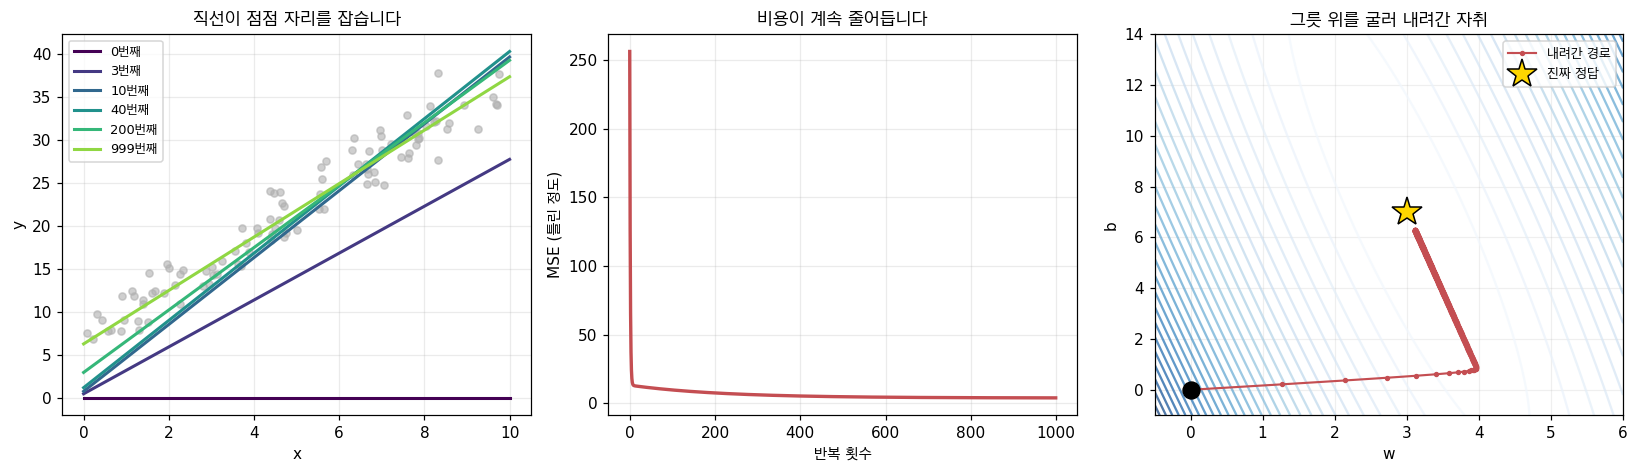

세 그림이 같은 이야기를 다르게 보여 줍니다.
  ① 직선이 데이터에 맞춰 회전하고 이동합니다
  ② 틀린 정도가 계속 줄어듭니다
  ③ 검은 점(시작)에서 노란 별(정답)까지 굴러갔습니다

💡 ③번을 보면 처음엔 크게 움직이다가 나중엔 조금씩 움직입니다.
   경사가 가파른 곳에서는 큰 걸음, 완만한 곳에서는 작은 걸음이 나오기 때문입니다.


In [9]:
# 학습 과정을 다시 돌리면서 중간중간 저장합니다
스냅샷 = []
연습모델 = 선형회귀(학습률=0.005)
for 회차 in range(1000):
    if 회차 in (0, 3, 10, 40, 200, 999):
        스냅샷.append((회차, 연습모델.w, 연습모델.b, 연습모델.비용(X, y)))
    dw, db = 연습모델.기울기(X, y)
    연습모델.w -= 연습모델.학습률 * dw
    연습모델.b -= 연습모델.학습률 * db

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# ① 직선이 점점 자리를 잡는 모습
xs = np.linspace(0, 10, 50)
axes[0].scatter(X, y, s=22, color="#b0b0b0", alpha=0.6)
색깔 = plt.get_cmap("viridis")
for k, (회차, w_, b_, c_) in enumerate(스냅샷):
    axes[0].plot(xs, w_ * xs + b_, lw=2, color=색깔(k / len(스냅샷)),
                 label=f"{회차}번째")
axes[0].set_title("직선이 점점 자리를 잡습니다", fontsize=12)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].legend(fontsize=8.5); axes[0].grid(alpha=0.25)

# ② 비용이 줄어드는 모습
axes[1].plot(모델.비용기록, lw=2.2, color="#c44e52")
axes[1].set_xlabel("반복 횟수"); axes[1].set_ylabel("MSE (틀린 정도)")
axes[1].set_title("비용이 계속 줄어듭니다", fontsize=12)
axes[1].grid(alpha=0.25)

# ③ 그릇 위에서 공이 굴러가는 경로
w경로, b경로 = [], []
연습2 = 선형회귀(학습률=0.005)
for _ in range(1000):
    w경로.append(연습2.w); b경로.append(연습2.b)
    dw, db = 연습2.기울기(X, y)
    연습2.w -= 연습2.학습률 * dw
    연습2.b -= 연습2.학습률 * db

wg, bg = np.meshgrid(np.linspace(-0.5, 6, 120), np.linspace(-1, 14, 120))
비용맵 = np.array([[MSE_계산(w_, b_, X, y) for w_ in np.linspace(-0.5, 6, 120)]
                   for b_ in np.linspace(-1, 14, 120)])
axes[2].contour(wg, bg, 비용맵, levels=30, cmap="Blues", alpha=0.7)
axes[2].plot(w경로, b경로, "-o", ms=2.5, lw=1.4, color="#c44e52", label="내려간 경로")
axes[2].plot(w경로[0], b경로[0], "o", ms=11, color="black", zorder=5)
axes[2].plot(진짜_기울기, 진짜_절편, "*", ms=20, color="gold",
             markeredgecolor="black", zorder=5, label="진짜 정답")
axes[2].set_xlabel("w"); axes[2].set_ylabel("b")
axes[2].set_title("그릇 위를 굴러 내려간 자취", fontsize=12)
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("세 그림이 같은 이야기를 다르게 보여 줍니다.")
print("  ① 직선이 데이터에 맞춰 회전하고 이동합니다")
print("  ② 틀린 정도가 계속 줄어듭니다")
print("  ③ 검은 점(시작)에서 노란 별(정답)까지 굴러갔습니다")
print("\n💡 ③번을 보면 처음엔 크게 움직이다가 나중엔 조금씩 움직입니다.")
print("   경사가 가파른 곳에서는 큰 걸음, 완만한 곳에서는 작은 걸음이 나오기 때문입니다.")

## 5️⃣ 학습률 — 보폭을 잘못 정하면

> 📗 **원문** — "The learning rate controls step size..."

**학습률(learning rate)** 은 **한 걸음의 크기**입니다. 이걸 잘못 정하면 학습이 망합니다.

| 학습률 | 무슨 일이 일어나나 | 비유 |
| --- | --- | --- |
| **너무 작다** | 너무 조금씩 움직여서 **평생 못 내려감** | 개미 걸음으로 산 내려가기 |
| **적당하다** | 잘 내려가서 바닥 도착 | ✅ |
| **너무 크다** | 바닥을 **건너뛰어** 반대편으로 튕김. 점점 커지다 **폭발** | 산을 뛰어넘어 다른 산으로 |

원문이 권하는 시작값: **0.01, 0.001, 0.0001**

> 💡 학습률은 컴퓨터가 배우는 값이 아니라 **사람이 정해 주는 값**입니다.
> 이런 걸 **하이퍼파라미터**라고 부릅니다 (1단원 용어 사전 참고).

> ✨ **추가 실험** — 학습률을 바꿔 가며 직접 망가뜨려 봅시다.

In [10]:
# ✨ 추가 — 학습률을 바꿔 가며 1000번씩 학습시켜 봅니다
print("학습률만 바꿔서 1000번씩 학습시켜 보겠습니다.\n")
print(f"{'학습률':>10}{'최종 w':>14}{'최종 b':>12}{'최종 비용':>14}{'결과':>14}")
print("-" * 66)

기록모음 = {}
for lr in [0.00001, 0.001, 0.005, 0.03, 0.05]:
    m = 선형회귀(학습률=lr)
    with np.errstate(over="ignore", invalid="ignore"):
        m.학습(X, y, 반복=1000, 조용히=True)     # 표가 깨지지 않게 출력을 끕니다
    기록모음[lr] = m.비용기록
    최종 = m.비용기록[-1]
    if not np.isfinite(최종):
        결과 = "폭발 💥"
    elif 최종 > 100:
        결과 = "너무 느림"
    elif 최종 < 5:
        결과 = "성공 ✓"
    else:
        결과 = "아쉬움"
    w표시 = f"{m.w:.3f}" if np.isfinite(m.w) else "무한대"
    b표시 = f"{m.b:.3f}" if np.isfinite(m.b) else "무한대"
    비용표시 = f"{최종:.4f}" if np.isfinite(최종) else "무한대"
    print(f"{lr:>10}{w표시:>14}{b표시:>12}{비용표시:>14}{결과:>14}")

print(f"\n(진짜 정답: w = {진짜_기울기}, b = {진짜_절편})")
print("\n=> 0.00001은 너무 작아서 1000번을 걸어도 산 중턱에 있습니다.")
print("   0.05는 너무 커서 튕겨 나가 숫자가 무한대가 됐습니다.")
print("   0.005 ~ 0.03 사이가 잘 됩니다.")

# ✨ 추가 — 폭발이 시작되는 정확한 지점을 찾아봅니다
# ⚠️ 주의: 한계를 살짝 넘으면 '천천히' 발산해서, 짧게 돌리면 멀쩡해 보입니다.
#          그래서 반복 횟수를 늘려 가며 봐야 합니다.
print("\n【 그럼 정확히 얼마부터 폭발할까요? 】")
print(f"{'학습률':>10}{'1000회 뒤':>16}{'5000회 뒤':>16}{'판정':>12}")
print("-" * 56)
for lr in [0.030, 0.031, 0.032, 0.035, 0.040]:
    단계별비용 = []          # (2절의 '비용들'과 이름이 겹치지 않게 다른 이름을 씁니다)
    for 반복수 in [1000, 5000]:
        m = 선형회귀(학습률=lr)
        with np.errstate(over="ignore", invalid="ignore"):
            m.학습(X, y, 반복=반복수, 조용히=True)
        단계별비용.append(m.비용기록[-1])
    # 값이 커지고 있으면 발산입니다 (무한대가 될 때까지 기다릴 필요 없음)
    발산중 = ((not np.isfinite(단계별비용[1]))
              or 단계별비용[1] > 단계별비용[0] or 단계별비용[1] > 1e4)
    표시 = [f"{v:.3f}" if np.isfinite(v) and v < 1e4 else
            (f"{v:.1e}" if np.isfinite(v) else "무한대") for v in 단계별비용]
    print(f"{lr:>10.3f}{표시[0]:>16}{표시[1]:>16}{'폭발 💥' if 발산중 else '정상':>12}")

# 이론적으로 계산할 수도 있습니다
X행렬_ = np.c_[np.ones(len(X)), X]
헤시안 = (2 / len(X)) * (X행렬_.T @ X행렬_)
한계 = 2 / np.linalg.eigvalsh(헤시안).max()
print(f"\n  이론적 한계값 = 2 / (가장 큰 고유값) = {한계:.5f}")
print(f"  실험에서도 {한계:.3f} 근처에서 갈립니다. 잘 맞네요.")

print("\n  ⚠️ 여기서 중요한 교훈이 하나 있습니다.")
print("     0.032는 1000회 시점에 비용이 '2.8e+36'이었습니다. 무한대가 아니니")
print("     프로그램은 멀쩡히 돌아갑니다. 하지만 이미 망한 상태예요.")
print("     => '에러가 안 났으니 잘 되고 있겠지'라고 믿으면 안 됩니다.")
print("        비용이 '줄어들고 있는지'를 꼭 눈으로 확인하세요.")

print("\n  💡 이 한계는 데이터에 따라 달라집니다. 그래서 '만능 학습률'은 없고,")
print("     보통 작은 값부터 시작해 조금씩 키우며 찾습니다.")

학습률만 바꿔서 1000번씩 학습시켜 보겠습니다.

       학습률          최종 w        최종 b         최종 비용            결과
------------------------------------------------------------------
     1e-05         1.883       0.327      159.3526         너무 느림
     0.001         3.636       2.962        7.5262           아쉬움
     0.005         3.112       6.287        3.9243          성공 ✓
      0.03         3.015       6.897        3.8355          성공 ✓
      0.05           무한대         무한대           무한대          폭발 💥

(진짜 정답: w = 3.0, b = 7.0)

=> 0.00001은 너무 작아서 1000번을 걸어도 산 중턱에 있습니다.
   0.05는 너무 커서 튕겨 나가 숫자가 무한대가 됐습니다.
   0.005 ~ 0.03 사이가 잘 됩니다.

【 그럼 정확히 얼마부터 폭발할까요? 】
       학습률         1000회 뒤         5000회 뒤          판정
--------------------------------------------------------
     0.030           3.835           3.835          정상
     0.031           3.835           3.835          정상
     0.032         2.8e+36        2.5e+171        폭발 💥
     0.035        1.3e+183             무한대        폭발 💥
     0.040             무한

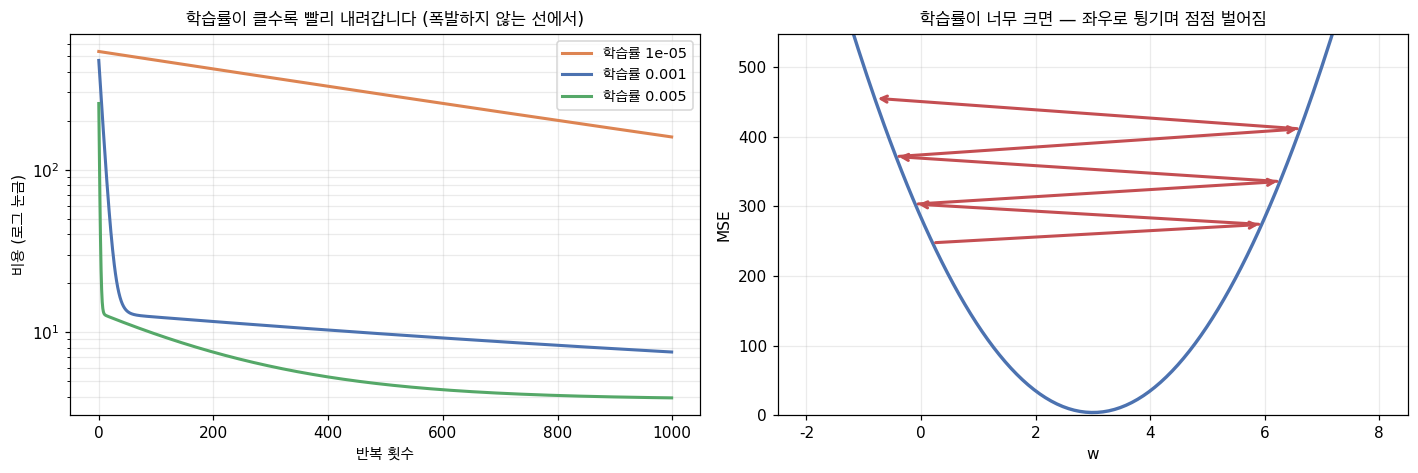

오른쪽 그림의 빨간 화살표를 보세요.
한 걸음이 너무 커서 바닥을 지나쳐 반대편으로 갑니다.
그리고 반대편은 더 가파르니까 다음 걸음은 더 커집니다. 그래서 폭발합니다.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

for lr, c in zip([0.00001, 0.001, 0.005], ["#dd8452", "#4c72b0", "#55a868"]):
    기록 = np.array(기록모음[lr])
    기록 = np.where(np.isfinite(기록), 기록, np.nan)
    ax1.semilogy(기록, lw=2, color=c, label=f"학습률 {lr}")
ax1.set_xlabel("반복 횟수"); ax1.set_ylabel("비용 (로그 눈금)")
ax1.set_title("학습률이 클수록 빨리 내려갑니다 (폭발하지 않는 선에서)", fontsize=11.5)
ax1.legend(fontsize=9.5); ax1.grid(alpha=0.25, which="both")

# 너무 큰 학습률이 튕겨 나가는 모습 (w 하나만 놓고)
ax2.plot(w_후보, 비용들, lw=2.2, color="#4c72b0")
w_현재 = 0.2
for step in range(6):
    비용현재 = MSE_계산(w_현재, 진짜_절편, X, y)
    기울기_ = (2 / len(X)) * np.sum((w_현재 * X + 진짜_절편 - y) * X)
    w_다음 = w_현재 - 0.033 * 기울기_
    if abs(w_다음) > 8:
        break
    ax2.annotate("", xy=(w_다음, MSE_계산(w_다음, 진짜_절편, X, y)),
                 xytext=(w_현재, 비용현재),
                 arrowprops=dict(arrowstyle="->", lw=2, color="#c44e52"))
    w_현재 = w_다음
ax2.set_xlabel("w"); ax2.set_ylabel("MSE")
ax2.set_title("학습률이 너무 크면 — 좌우로 튕기며 점점 벌어짐", fontsize=11.5)
ax2.set_ylim(0, max(비용들) * 0.7)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("오른쪽 그림의 빨간 화살표를 보세요.")
print("한 걸음이 너무 커서 바닥을 지나쳐 반대편으로 갑니다.")
print("그리고 반대편은 더 가파르니까 다음 걸음은 더 커집니다. 그래서 폭발합니다.")

## 6️⃣ 정규방정식 — 한 번에 푸는 공식

> 📗 **원문** — "The Normal Equation (Closed-Form Solution)"

사실 선형 회귀에는 **반복 없이 한 번에 답을 주는 공식**이 있습니다.

$$w = (X^\top X)^{-1} X^\top y$$

행렬 하나를 뒤집으면(역행렬) 끝입니다. 산을 내려갈 필요가 없어요.

### 🤔 그러면 왜 경사하강법을 배웠나요

**두 가지 이유가 있습니다.**

**① 이 공식은 선형 회귀에만 있습니다.**
로지스틱 회귀(3단원)부터는 이런 공식이 없어요. 경사하강법밖에 없습니다.
그리고 **신경망은 전부 경사하강법**입니다.

**② 데이터가 크면 이 공식이 더 느립니다.**
역행렬 계산은 특징 개수의 **세제곱**에 비례합니다.
특징이 1000개면 10억 번 계산이에요. 경사하강법이 훨씬 낫습니다.

| | 정규방정식 | 경사하강법 |
| --- | --- | --- |
| 반복 | 없음 (한 번에) | 수백~수천 번 |
| 학습률 | 필요 없음 | 정해 줘야 함 |
| 특징이 적을 때 | **✅ 빠르고 정확** | 느림 |
| 특징이 많을 때 | ❌ 아주 느림 | **✅ 잘 됨** |
| 다른 알고리즘에도 쓰나 | ❌ 선형 회귀 전용 | **✅ 거의 전부** |

In [12]:
def 정규방정식_풀이(X, y):
    # X 앞에 1로 채운 열을 붙입니다 (b, 즉 절편을 함께 구하려고)
    X행렬 = np.c_[np.ones(len(X)), X]
    # w = (XᵀX)⁻¹ Xᵀ y  를 그대로 계산합니다
    # (실전에서는 역행렬 대신 np.linalg.solve를 쓰는 게 더 정확합니다)
    계수 = np.linalg.solve(X행렬.T @ X행렬, X행렬.T @ y)
    return 계수[0], 계수[1]        # b, w

b_공식, w_공식 = 정규방정식_풀이(X, y)

print("두 방법 비교\n")
print(f"{'방법':<22}{'w':>12}{'b':>12}{'MSE':>12}")
print("-" * 58)
print(f"{'경사하강법 (1000번)':<20}{모델.w:>12.5f}{모델.b:>12.5f}"
      f"{MSE_계산(모델.w, 모델.b, X, y):>12.5f}")
print(f"{'정규방정식 (한 번에)':<20}{w_공식:>12.5f}{b_공식:>12.5f}"
      f"{MSE_계산(w_공식, b_공식, X, y):>12.5f}")
print(f"{'진짜 정답':<22}{진짜_기울기:>12.5f}{진짜_절편:>12.5f}"
      f"{MSE_계산(진짜_기울기, 진짜_절편, X, y):>12.5f}")

print("\n=> 정규방정식이 아주 조금 더 좋은 답을 냈습니다. 정확한 공식이니까요.")
print("   경사하강법은 1000번 걸어서 '거의' 도착한 상태입니다.")
print("   더 오래 걸으면 똑같아집니다.\n")

print("⚠️ 그런데 '진짜 정답'의 MSE가 두 방법보다 살짝 큽니다. 왜일까요?")
print(f"   진짜 정답 MSE {MSE_계산(진짜_기울기, 진짜_절편, X, y):.5f} vs "
      f"정규방정식 MSE {MSE_계산(w_공식, b_공식, X, y):.5f}")
print("   우리 데이터에는 잡음이 섞여 있어서, 이 100개 점에 '가장 잘 맞는' 직선은")
print("   진짜 직선과 미세하게 다릅니다. 이건 오류가 아니라 당연한 현상입니다.")

두 방법 비교

방법                               w           b         MSE
----------------------------------------------------------
경사하강법 (1000번)            3.11160     6.28679     3.92433
정규방정식 (한 번에)             3.01533     6.89740     3.83546
진짜 정답                      3.00000     7.00000     3.83798

=> 정규방정식이 아주 조금 더 좋은 답을 냈습니다. 정확한 공식이니까요.
   경사하강법은 1000번 걸어서 '거의' 도착한 상태입니다.
   더 오래 걸으면 똑같아집니다.

⚠️ 그런데 '진짜 정답'의 MSE가 두 방법보다 살짝 큽니다. 왜일까요?
   진짜 정답 MSE 3.83798 vs 정규방정식 MSE 3.83546
   우리 데이터에는 잡음이 섞여 있어서, 이 100개 점에 '가장 잘 맞는' 직선은
   진짜 직선과 미세하게 다릅니다. 이건 오류가 아니라 당연한 현상입니다.


## 7️⃣ 입력이 여러 개일 때 + 스케일 맞추기

> 📗 **원문** — "Multiple Linear Regression"

집 크기 하나만 쓰지 말고 **방 개수, 지은 연도**도 함께 쓰면 더 잘 맞겠죠.

$$y = w_1x_1 + w_2x_2 + w_3x_3 + b$$

**계산 방식은 똑같습니다.** MSE를 쓰고, 경사하강법으로 모든 `w`를 동시에 고칩니다.
차이는 직선 대신 **평면(또는 초평면)** 을 맞춘다는 것뿐이에요.

### ⚠️ 그런데 여기서 큰 함정이 하나 있습니다

> 📗 **원문** — "Feature scaling matters here."

특징들의 **숫자 크기가 너무 다르면** 경사하강법이 헤맵니다.

- 집 크기: 0 ~ 100
- 방 개수: 1 ~ 5
- 건축 연도: 1990 ~ 2024

**연도 값이 다른 것보다 수백 배 큽니다.** 그러면 그릇이 **길쭉하게 찌그러져서**
공이 굴러 내려가지 못하고 지그재그로 헤맵니다.

### 해결책 — 표준화 (Standardization)

$$x_{\text{새로운}} = \frac{x - \text{평균}}{\text{표준편차}}$$

이러면 모든 특징이 **평균 0, 표준편차 1**로 맞춰집니다. 그릇이 동그래져요.

> ✨ **추가 실험** — 스케일을 안 맞추면 정말 문제가 생기는지 확인합니다.

In [13]:
# ✨ 추가 — 크기가 아주 다른 특징 3개로 실험합니다
rng2 = np.random.default_rng(7)
n = 200
크기 = rng2.uniform(20, 100, n)        # 20 ~ 100
방개수 = rng2.integers(1, 6, n).astype(float)   # 1 ~ 5
연도 = rng2.uniform(1990, 2024, n)     # 1990 ~ 2024  <- 훨씬 큼!

X다중 = np.c_[크기, 방개수, 연도]
진짜계수 = np.array([2.5, 8.0, 0.3])
y다중 = X다중 @ 진짜계수 + 50 + rng2.normal(0, 10, n)

print("특징들의 숫자 범위를 보면\n")
print(f"{'특징':>10}{'최솟값':>12}{'최댓값':>12}{'평균':>12}{'표준편차':>12}")
print("-" * 60)
for 이름, 열 in zip(["크기", "방개수", "연도"], X다중.T):
    print(f"{이름:>10}{열.min():>12.1f}{열.max():>12.1f}{열.mean():>12.1f}{열.std():>12.1f}")
print("\n=> '연도'가 다른 것보다 수십~수백 배 큽니다. 이게 문제를 일으킵니다.")

def 다중회귀_학습(X, y, 학습률, 반복=3000):
    w = np.zeros(X.shape[1]); b = 0.0
    기록 = []
    with np.errstate(over="ignore", invalid="ignore"):
        for _ in range(반복):
            오차 = (X @ w + b) - y
            w -= 학습률 * (2 / len(y)) * (X.T @ 오차)
            b -= 학습률 * (2 / len(y)) * 오차.sum()
            기록.append(np.mean(오차 ** 2))
    return w, b, 기록

# 표준화: (값 - 평균) / 표준편차
X표준 = (X다중 - X다중.mean(axis=0)) / X다중.std(axis=0)

w1, b1, 기록1 = 다중회귀_학습(X다중, y다중, 0.0001)
w2, b2, 기록2 = 다중회귀_학습(X표준, y다중, 0.0001)
w3, b3, 기록3 = 다중회귀_학습(X표준, y다중, 0.05)

def 비용표시(v):
    return f"{v:,.1f}" if np.isfinite(v) else "폭발 💥"

print("\n3000번씩 학습시킨 결과\n")
print(f"{'설정':<30}{'학습률':>10}{'최종 비용':>16}")
print("-" * 58)
print(f"{'① 스케일 그대로':<28}{0.0001:>10}{비용표시(기록1[-1]):>16}")
print(f"{'② 표준화함':<29}{0.0001:>10}{비용표시(기록2[-1]):>16}")
print(f"{'③ 표준화 + 학습률 키움':<25}{0.05:>10}{비용표시(기록3[-1]):>16}")

print("\n=> ①은 학습률 0.0001에서도 폭발합니다. '연도' 값이 2000쯤 되니")
print("   기울기가 어마어마하게 커지기 때문입니다.")
print("   ②는 폭발은 안 하지만, 학습률이 너무 작아서 3000번을 걸어도 멀었습니다.")
print("   ③처럼 표준화한 뒤 학습률을 키워야 제대로 도착합니다.")
print("\n   💡 핵심: 표준화의 진짜 이득은 '큰 학습률을 안전하게 쓸 수 있게 되는 것'입니다.")

특징들의 숫자 범위를 보면

        특징         최솟값         최댓값          평균        표준편차
------------------------------------------------------------
        크기        20.3        99.6        60.2        23.3
       방개수         1.0         5.0         3.0         1.4
        연도      1990.5      2024.0      2007.7         9.4

=> '연도'가 다른 것보다 수십~수백 배 큽니다. 이게 문제를 일으킵니다.

3000번씩 학습시킨 결과

설정                                   학습률           최종 비용
----------------------------------------------------------
① 스케일 그대로                       0.0001            폭발 💥
② 표준화함                           0.0001       206,844.3
③ 표준화 + 학습률 키움                 0.05            83.1

=> ①은 학습률 0.0001에서도 폭발합니다. '연도' 값이 2000쯤 되니
   기울기가 어마어마하게 커지기 때문입니다.
   ②는 폭발은 안 하지만, 학습률이 너무 작아서 3000번을 걸어도 멀었습니다.
   ③처럼 표준화한 뒤 학습률을 키워야 제대로 도착합니다.

   💡 핵심: 표준화의 진짜 이득은 '큰 학습률을 안전하게 쓸 수 있게 되는 것'입니다.


/opt/homebrew/anaconda3/lib/python3.11/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


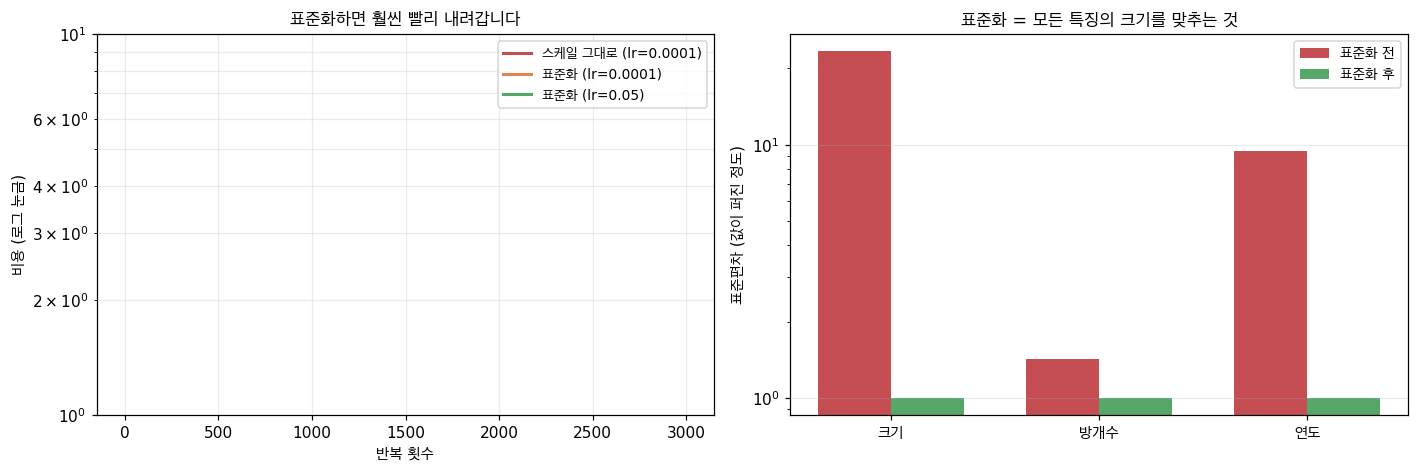

오른쪽 그림: 표준화 전에는 특징마다 퍼진 정도가 제각각인데,
표준화 후에는 전부 1로 맞춰졌습니다.

💡 실무 규칙: 경사하강법을 쓸 거면 '항상' 특징을 표준화하세요.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

for 기록, 이름, c in [(기록1, "스케일 그대로 (lr=0.0001)", "#c44e52"),
                     (기록2, "표준화 (lr=0.0001)", "#dd8452"),
                     (기록3, "표준화 (lr=0.05)", "#55a868")]:
    기록arr = np.array(기록, dtype=float)
    기록arr = np.where(np.isfinite(기록arr), 기록arr, np.nan)
    ax1.semilogy(기록arr, lw=2, label=이름, color=c)
ax1.set_xlabel("반복 횟수"); ax1.set_ylabel("비용 (로그 눈금)")
ax1.set_title("표준화하면 훨씬 빨리 내려갑니다", fontsize=11.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.25, which="both")

# 표준화 전후의 값 분포
위치 = np.arange(3)
폭 = 0.35
ax2.bar(위치 - 폭/2, X다중.std(axis=0), 폭, label="표준화 전", color="#c44e52")
ax2.bar(위치 + 폭/2, X표준.std(axis=0), 폭, label="표준화 후", color="#55a868")
ax2.set_xticks(위치); ax2.set_xticklabels(["크기", "방개수", "연도"])
ax2.set_ylabel("표준편차 (값이 퍼진 정도)")
ax2.set_yscale("log")
ax2.set_title("표준화 = 모든 특징의 크기를 맞추는 것", fontsize=11.5)
ax2.legend(fontsize=9.5); ax2.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

print("오른쪽 그림: 표준화 전에는 특징마다 퍼진 정도가 제각각인데,")
print("표준화 후에는 전부 1로 맞춰졌습니다.")
print("\n💡 실무 규칙: 경사하강법을 쓸 거면 '항상' 특징을 표준화하세요.")

## 8️⃣ 다항 회귀 — 곡선도 직선으로

> 📗 **원문** — "Polynomial Regression"

데이터가 **직선이 아니라 곡선**을 그리면 어떡할까요?

놀랍게도 **선형 회귀를 그대로 쓸 수 있습니다.** 이렇게요.

$$y = w_1x + w_2x^2 + w_3x^3 + b$$

`x` 말고 **`x²`, `x³`도 새로운 특징으로 만들어서** 넣는 겁니다.

### 🤔 잠깐, 이게 왜 아직도 '선형'인가요

> 📗 **원문** — "This is still 'linear' regression because the model is linear in the weights."

**`x`에 대해 선형이 아니라, `w`에 대해 선형**이기 때문입니다.

`w₁`, `w₂`, `w₃`가 전부 **1차로만** 등장하죠. `w²` 같은 건 없습니다.
컴퓨터 입장에서는 그냥 "특징이 3개인 선형 회귀"일 뿐이에요.

> 🧸 **비유:** `x²`을 "새로운 재료"라고 생각하세요.
> 밀가루(x)만 쓰다가 설탕(x²)과 버터(x³)를 추가한 겁니다.
> 레시피(선형 결합)는 그대로예요.

### ⚠️ 차수를 너무 높이면

1단원 6절에서 본 **과적합**이 일어납니다.
10차 다항식은 10개 점을 **전부 정확히** 지나가지만, 새 데이터에서는 엉망입니다.

In [15]:
# 곡선 데이터를 만들고 다항 회귀를 해 봅니다
rng3 = np.random.default_rng(0)
X곡선 = np.sort(rng3.uniform(-3, 3, 40))
y곡선 = 0.5 * X곡선**3 - 2 * X곡선 + rng3.normal(0, 2.0, 40)

def 다항특징(X, 차수):
    # x, x², x³, ... 을 만들어 나란히 붙입니다
    return np.column_stack([X ** k for k in range(1, 차수 + 1)])

print("차수를 올려 가며 얼마나 잘 맞는지 봅니다\n")
print(f"{'차수':>6}{'만든 특징':>28}{'MSE':>12}")
print("-" * 48)
for 차수 in [1, 2, 3, 5]:
    특징 = 다항특징(X곡선, 차수)
    X행렬 = np.c_[np.ones(len(X곡선)), 특징]
    계수 = np.linalg.solve(X행렬.T @ X행렬, X행렬.T @ y곡선)
    예측 = X행렬 @ 계수
    특징이름 = ", ".join(f"x^{k}" if k > 1 else "x" for k in range(1, 차수+1))
    print(f"{차수:>6}{특징이름:>28}{np.mean((예측-y곡선)**2):>12.4f}")

print("\n=> 진짜 관계가 3차식(x³)이라서, 차수 2 -> 3 에서 MSE가 뚝 떨어집니다(11.1 -> 4.3).")
print("   차수 1(직선)로는 절대 못 맞춥니다.")
print("\n⚠️ 그런데 차수 5가 차수 3보다 MSE가 조금 더 낮습니다. 더 좋은 걸까요?")
print("   아닙니다. 이건 '훈련 데이터'로 잰 점수예요.")
print("   훈련 MSE는 차수를 올리면 '항상' 내려갑니다 (1단원 6절에서 봤죠).")
print("   진짜 실력은 '처음 보는 데이터'로 재야 합니다. 연습문제 2번에서 해 보세요.")

차수를 올려 가며 얼마나 잘 맞는지 봅니다

    차수                       만든 특징         MSE
------------------------------------------------
     1                           x     11.2592
     2                      x, x^2     11.0992
     3                 x, x^2, x^3      4.3176
     5       x, x^2, x^3, x^4, x^5      3.9802

=> 진짜 관계가 3차식(x³)이라서, 차수 2 -> 3 에서 MSE가 뚝 떨어집니다(11.1 -> 4.3).
   차수 1(직선)로는 절대 못 맞춥니다.

⚠️ 그런데 차수 5가 차수 3보다 MSE가 조금 더 낮습니다. 더 좋은 걸까요?
   아닙니다. 이건 '훈련 데이터'로 잰 점수예요.
   훈련 MSE는 차수를 올리면 '항상' 내려갑니다 (1단원 6절에서 봤죠).
   진짜 실력은 '처음 보는 데이터'로 재야 합니다. 연습문제 2번에서 해 보세요.


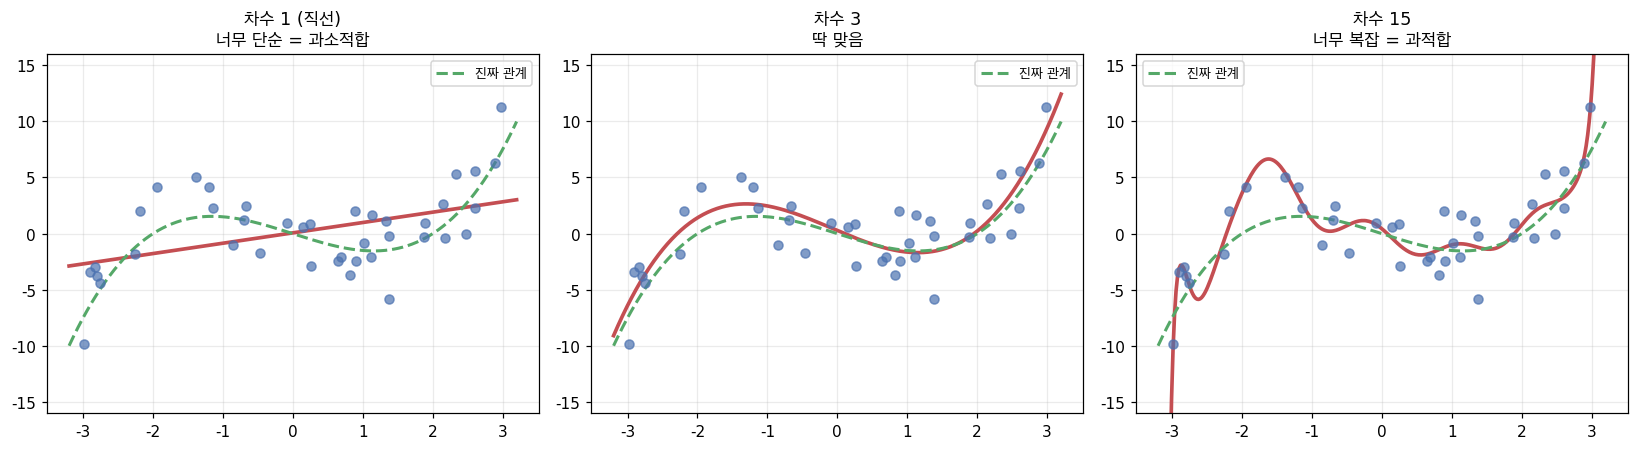

가운데(차수 3)가 진짜 관계(초록 점선)와 거의 겹칩니다.
오른쪽(차수 15)은 점들 사이에서 이상하게 출렁입니다 — 잡음까지 따라간 겁니다.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
xs곡선 = np.linspace(-3.2, 3.2, 300)

for ax, 차수 in zip(axes, [1, 3, 15]):
    특징 = 다항특징(X곡선, 차수)
    X행렬 = np.c_[np.ones(len(X곡선)), 특징]
    계수 = np.linalg.solve(X행렬.T @ X행렬 + 1e-8*np.eye(차수+1), X행렬.T @ y곡선)
    그릴특징 = np.c_[np.ones(len(xs곡선)), 다항특징(xs곡선, 차수)]
    ax.scatter(X곡선, y곡선, s=35, color="#4c72b0", alpha=0.7, zorder=5)
    ax.plot(xs곡선, 그릴특징 @ 계수, lw=2.4, color="#c44e52")
    ax.plot(xs곡선, 0.5*xs곡선**3 - 2*xs곡선, lw=2, color="#55a868", ls="--",
            label="진짜 관계")
    설명 = {1: "차수 1 (직선)\n너무 단순 = 과소적합",
            3: "차수 3\n딱 맞음",
            15: "차수 15\n너무 복잡 = 과적합"}[차수]
    ax.set_title(설명, fontsize=11.5)
    ax.set_ylim(-16, 16)
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("가운데(차수 3)가 진짜 관계(초록 점선)와 거의 겹칩니다.")
print("오른쪽(차수 15)은 점들 사이에서 이상하게 출렁입니다 — 잡음까지 따라간 겁니다.")

## 9️⃣ R² 점수 — 몇 점짜리 모델인가

> 📗 **원문** — "R-Squared Score"

MSE는 **얼마나 틀렸는지**를 알려주지만, **숫자 크기에 좌우됩니다.**

집값을 '원' 단위로 재면 MSE가 수십억이 나오고, '억원' 단위로 재면 0.1이 나옵니다.
**같은 모델인데 점수가 완전히 다르죠.**

그래서 **크기와 무관한 점수**가 필요합니다. 그게 **R²(결정계수)** 입니다.

$$R^2 = 1 - \frac{\text{내 모델이 틀린 정도}}{\text{그냥 평균으로 답했을 때 틀린 정도}}$$

### 🧸 말로 풀면

**"아무 생각 없이 평균만 말하는 것보다 얼마나 나은가"** 를 재는 점수입니다.

| R² | 뜻 |
| --- | --- |
| **1.0** | 완벽하게 맞힘 |
| **0.7** | 평균보다 70% 나음 (꽤 좋음) |
| **0.0** | **평균만 말하는 것과 똑같음** (배운 게 없음) |
| **음수** | 평균보다도 못함 (모델이 잘못됨) |

> 🔑 1단원에서 배운 **"기준선과 비교하라"** 가 여기 녹아 있습니다.
> R²의 기준선이 바로 **"항상 평균을 답하기"** 입니다.

In [17]:
def R2계산(실제, 예측):
    잔차제곱합 = np.sum((실제 - 예측) ** 2)          # 내 모델의 오차
    전체제곱합 = np.sum((실제 - 실제.mean()) ** 2)   # 평균으로 답했을 때의 오차
    return 1 - 잔차제곱합 / 전체제곱합

print("여러 예측 방식의 R² 점수\n")
print(f"{'방식':<32}{'MSE':>12}{'R²':>12}{'해석':>20}")
print("-" * 78)

방식들 = [
    ("① 우리 모델 (경사하강법)", 모델.예측(X)),
    ("② 정규방정식", w_공식 * X + b_공식),
    ("③ 항상 평균만 답하기", np.full_like(y, y.mean())),
    ("④ 항상 0이라고 답하기", np.zeros_like(y)),
]
for 이름, 예측 in 방식들:
    r2 = R2계산(y, 예측)
    해석 = ("아주 좋음" if r2 > 0.9 else "좋음" if r2 > 0.5
            else "배운 게 없음" if abs(r2) < 0.01 else "평균보다 나쁨")
    print(f"{이름:<30}{np.mean((예측-y)**2):>12.3f}{r2:>12.4f}{해석:>20}")

print("\n=> ③번(항상 평균)의 R²가 정확히 0입니다. 이게 R²의 기준선입니다.")
print("   ④번은 음수예요. 평균만 말하는 것보다도 못하다는 뜻입니다.")

여러 예측 방식의 R² 점수

방식                                       MSE          R²                  해석
------------------------------------------------------------------------------
① 우리 모델 (경사하강법)                      3.924      0.9449               아주 좋음
② 정규방정식                              3.835      0.9462               아주 좋음
③ 항상 평균만 답하기                        71.226      0.0000             배운 게 없음
④ 항상 0이라고 답하기                      536.644     -6.5344             평균보다 나쁨

=> ③번(항상 평균)의 R²가 정확히 0입니다. 이게 R²의 기준선입니다.
   ④번은 음수예요. 평균만 말하는 것보다도 못하다는 뜻입니다.


## 🔟 릿지 회귀 맛보기

> 📗 **원문** — "Regularization Preview (Ridge Regression)"
>
> 원문도 "맛보기"라고 했습니다. **나중 단원에서 자세히 다룹니다.**
> 지금은 "이런 게 있고 왜 필요한지" 정도만 아셔도 충분합니다.

특징이 많아지면 모델이 **가중치를 아주 크게** 만들어서 과적합할 수 있습니다.

**릿지 회귀**는 비용 함수에 **벌점**을 추가합니다.

$$\text{비용} = \text{MSE} + \lambda \sum w_i^2$$

### 🧸 말로 풀면

> **"틀리는 것도 싫지만, 가중치가 커지는 것도 싫다."**

`λ`(람다)가 그 균형을 정합니다.
- `λ`가 크면 → 가중치를 아주 작게 유지 (단순한 모델)
- `λ`가 0이면 → 그냥 보통 선형 회귀

### 🤔 왜 가중치가 크면 안 좋나요

가중치가 크다는 건 **입력이 조금만 변해도 출력이 확 변한다**는 뜻입니다.
그러면 데이터의 **잡음에도 민감하게 반응**해서 과적합이 됩니다.

In [18]:
def 릿지_풀이(X특징, y, 람다):
    X행렬 = np.c_[np.ones(len(X특징)), X특징]
    n = X행렬.shape[1]
    벌점 = 람다 * np.eye(n)
    벌점[0, 0] = 0            # 절편(b)에는 벌점을 안 줍니다
    return np.linalg.solve(X행렬.T @ X행렬 + 벌점, X행렬.T @ y)

# 8절의 과적합 상황(차수 15)에 릿지를 적용해 봅니다
특징15 = 다항특징(X곡선, 15)
print("차수 15 다항식에 릿지 벌점을 주면\n")
print(f"{'λ (벌점 크기)':>16}{'가중치 크기 합':>18}{'훈련 MSE':>14}")
print("-" * 50)
for 람다 in [0.0, 0.01, 1.0, 100.0]:
    계수 = 릿지_풀이(특징15, y곡선, 람다)
    예측 = np.c_[np.ones(len(X곡선)), 특징15] @ 계수
    print(f"{람다:>16.2f}{np.sum(계수[1:]**2):>18.4f}"
          f"{np.mean((예측-y곡선)**2):>14.4f}")

print("\n=> λ를 키우면 가중치 크기가 확 줄어듭니다.")
print("   대신 훈련 MSE는 조금 나빠집니다. 이게 '거래(trade-off)'입니다.")
print("   훈련 데이터를 조금 덜 맞히는 대신, 새 데이터에서 더 잘 맞게 되는 거죠.")

차수 15 다항식에 릿지 벌점을 주면

       λ (벌점 크기)          가중치 크기 합        훈련 MSE
--------------------------------------------------
            0.00          726.6519        2.7573
            0.01          159.8256        2.8007
            1.00            1.4638        2.9306
          100.00            0.1221        3.4125

=> λ를 키우면 가중치 크기가 확 줄어듭니다.
   대신 훈련 MSE는 조금 나빠집니다. 이게 '거래(trade-off)'입니다.
   훈련 데이터를 조금 덜 맞히는 대신, 새 데이터에서 더 잘 맞게 되는 거죠.


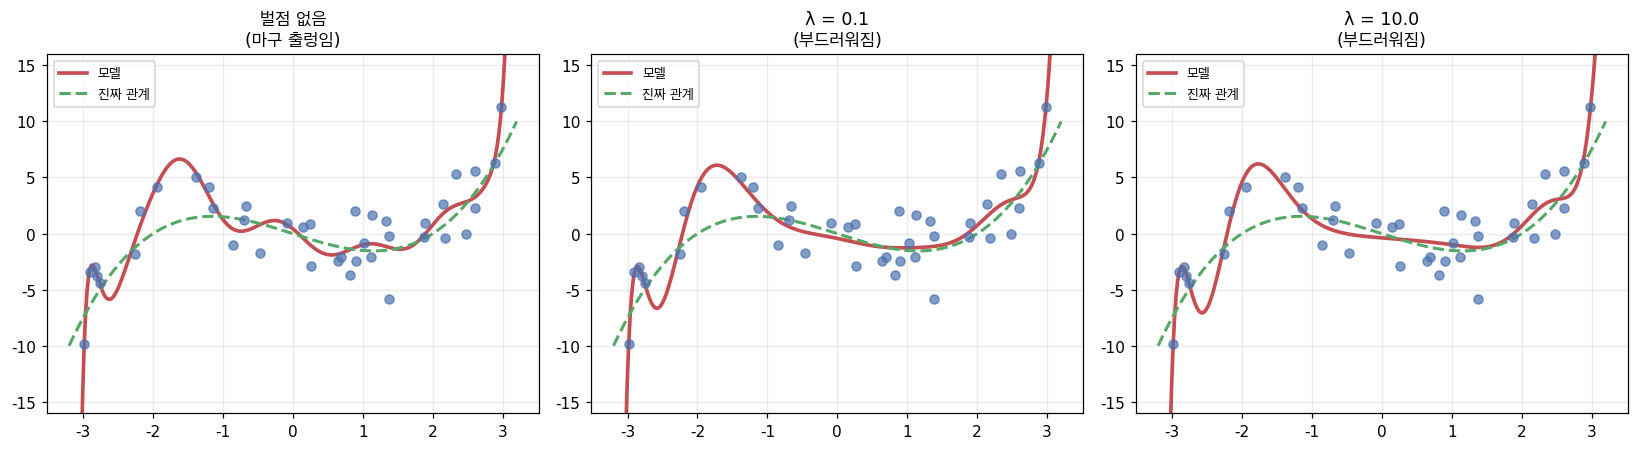

왼쪽(벌점 없음)은 점 사이에서 요동칩니다.
오른쪽으로 갈수록 선이 부드러워지면서 진짜 관계(초록 점선)에 가까워집니다.

💡 벌점이 '너무 열심히 맞히려는 것'을 말려 준 겁니다.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, 람다 in zip(axes, [0.0, 0.1, 10.0]):
    계수 = 릿지_풀이(특징15, y곡선, 람다)
    그릴 = np.c_[np.ones(len(xs곡선)), 다항특징(xs곡선, 15)] @ 계수
    ax.scatter(X곡선, y곡선, s=35, color="#4c72b0", alpha=0.7, zorder=5)
    ax.plot(xs곡선, 그릴, lw=2.4, color="#c44e52", label="모델")
    ax.plot(xs곡선, 0.5*xs곡선**3 - 2*xs곡선, lw=2, color="#55a868", ls="--",
            label="진짜 관계")
    상태 = "벌점 없음\n(마구 출렁임)" if 람다 == 0 else f"λ = {람다}\n(부드러워짐)"
    ax.set_title(상태, fontsize=11.5)
    ax.set_ylim(-16, 16); ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("왼쪽(벌점 없음)은 점 사이에서 요동칩니다.")
print("오른쪽으로 갈수록 선이 부드러워지면서 진짜 관계(초록 점선)에 가까워집니다.")
print("\n💡 벌점이 '너무 열심히 맞히려는 것'을 말려 준 겁니다.")

## 1️⃣1️⃣ 용어 사전 · 연습문제

> 📗 **원문** — "Key Terms" · "Exercises"

### 용어 사전

| 용어 | 사람들이 하는 말 | 진짜 뜻 |
| --- | --- | --- |
| **선형 회귀** | "데이터에 선 긋기" | `wx+b`와 실제 `y`의 차이 제곱합을 최소로 만드는 `w`, `b` 찾기 |
| **비용 함수** | "얼마나 나쁜가" | 파라미터를 넣으면 '틀린 정도'를 숫자 하나로 돌려주는 함수 |
| **평균제곱오차(MSE)** | "오차 제곱의 평균" | `(1/n)Σ(예측−실제)²`. 크게 틀린 걸 더 크게 벌줌 |
| **경사하강법** | "내리막 걷기" | 기울기를 보고 비용이 줄어드는 방향으로 조금씩 이동 |
| **학습률** | "보폭" | 한 번에 얼마나 움직일지 정하는 값. 사람이 정함 |
| **정규방정식** | "한 번에 풀기" | `w = (XᵀX)⁻¹Xᵀy`. 반복 없이 최적해를 주는 공식 |
| **R²** | "얼마나 잘 맞나" | 평균으로 답하는 것 대비 얼마나 나은지. 1이면 완벽, 0이면 평균과 같음 |
| **특징 스케일링** | "크기 맞추기" | 특징들을 비슷한 범위로 변환. 경사하강법이 빨라짐 |
| **정규화(규제)** | "복잡함에 벌점" | 비용에 항을 더해 가중치를 작게 유지 |
| **릿지 회귀** | "L2 규제" | MSE에 `λΣw²`를 더한 선형 회귀 |
| **다항 회귀** | "선형으로 곡선 맞추기" | `x, x², x³`을 특징으로 쓰는 선형 회귀 |
| **과적합** | "훈련 데이터 외우기" | 잡음까지 맞추려다 새 데이터에서 실패 |

---

### 연습문제

**1.** 학습률을 0.001, 0.01, 0.1로 바꿔 가며 학습시켜 보세요.
비용이 줄어드는 모습이 어떻게 다른가요? 폭발하는 값은 얼마부터인가요?

**2.** 데이터를 훈련용 80개 / 테스트용 20개로 나눈 뒤,
다항식 차수를 1부터 15까지 올려 가며 **훈련 MSE와 테스트 MSE**를 각각 재 보세요.
어디서 테스트 MSE가 최소가 되나요?

**3.** 7절의 다중 회귀에서, 표준화를 **하지 않고** 학습률을 키워 보세요.
어디서 폭발하나요? 표준화한 경우와 비교해 보세요.

**4.** R²가 **음수**가 나오는 예측을 하나 만들어 보세요.
(힌트: 평균보다 나쁘게 예측하면 됩니다)

---

## 🎯 이 단원 한 문장 정리

> **모델을 정하고 → 틀린 정도를 재는 법을 정하고 → 조금씩 고쳐 나간다.
> 이 3단계가 모든 머신러닝의 뼈대입니다.**

### 3단계 다시 보기

| 단계 | 이번 단원에서는 | 앞으로도 계속 |
| --- | --- | --- |
| ① **모델 정하기** | `y = wx + b` (직선) | 신경망, 트랜스포머... |
| ② **비용 정하기** | MSE (오차 제곱 평균) | 크로스 엔트로피 등 |
| ③ **최적화하기** | **경사하강법** | **거의 항상 경사하강법** |

③번이 특히 중요합니다. **ChatGPT를 학습시킬 때도 똑같은 경사하강법**을 씁니다.
모델이 훨씬 크고 복잡할 뿐, "발끝으로 더듬어 한 걸음 내딛기"는 똑같아요.

### 꼭 기억할 것

1. **비용 함수는 그릇 모양**이고, 학습은 바닥을 찾아가는 일입니다
2. **학습률이 너무 크면 폭발**하고, 너무 작으면 영원히 못 도착합니다
3. **특징 스케일을 맞추세요.** 안 그러면 그릇이 찌그러집니다
4. **R²는 "평균보다 얼마나 나은가"** 입니다

### 다음 단원 예고

3단원 **로지스틱 회귀**에서는 **"예/아니오"를 맞히는 법**을 배웁니다.
직선을 그대로 쓰면 왜 안 되는지, **시그모이드**라는 게 왜 필요한지 봅니다.

---

## 📖 더 읽을거리

> 📗 **원문** — "Further Reading"

- [An Introduction to Statistical Learning](https://www.statlearning.com/) — 3장이 선형 회귀입니다 (무료)
- [scikit-learn 선형 모델 문서](https://scikit-learn.org/stable/modules/linear_model.html) — 실무에서 쓰는 구현
- [3Blue1Brown: 경사하강법](https://www.youtube.com/watch?v=IHZwWFHWa-w) — 시각적으로 가장 좋은 설명